# Lecture 9 warm-up — Which one is the ethical option?

**AI-integrated Sustainable Finance (25881)**

Fifteen minutes, three rounds, keep score. By the end you will have
**reverse-engineered what the word "ethical" means in Australian
superannuation** — from the holdings alone, without reading a single product
disclosure statement.

### What you need

Nothing beyond `numpy`, `pandas` and `plotly`. No helper module, no network,
no data download: the thirty-one options you will look at are typed into the
next code cell. It runs on a locked-down machine, on Colab, or on a laptop you
borrowed thirty seconds ago.

### The rules

| Round | The game | Points |
|---|---|---|
| 1 | **Spot the label.** Six anonymous super options: which ones are sold as ethical? | 6 |
| 2 | **What gives it away?** Pick the category the label separates best, and the one it separates worst | 4 |
| 3 | **Write the industry's rule.** One category, one threshold, thirty-one options | 6 |

Play honestly. Guess *before* you run each reveal cell. The whole value is in
being wrong about something specific, and then finding out why.

## First, what the numbers mean

In 2026 Mindful Investing, an independent charity, went through the publicly
disclosed holdings of **thirty-one superannuation investment options** run by
fifteen of Australia's largest providers. For each provider it took the core
**MySuper default** — where your money goes if you never choose — plus one or
more **ethical options**, the ones sold as ethical, sustainable, socially
responsible or socially conscious.

For every option you get six numbers. Each is the **percentage of the analysed
portfolio invested in companies of concern** in one category:

| Category | What it covers |
|---|---|
| Fossil fuels | extracting, producing, refining or distributing coal, oil or gas, including fossil-fired power generation |
| Human rights | operating in occupied territories, or records of significant abuses such as labour-rights or public-safety failures |
| Environmental harm | deforestation, highly hazardous pesticides, palm oil, GMOs, and harm to the ocean |
| Social harm | tobacco, gambling, alcohol, adult entertainment and predatory lending |
| Animal cruelty | animal testing, factory farming, fur and speciality leather |
| Weapons | production and distribution of weapons |

A seventh number, **Total**, counts each company once even if it sits in
several categories, which is why it is less than the sum of the six.

*Source: Mindful Money (2026), Inside Australia's Super Funds: An Ethical Review
of Investment Portfolios, released under CC BY-NC 4.0. Holdings as at 30 June
2025. Categories paraphrased from the published methodology.*

In [1]:
# --- setup: numpy, pandas and plotly only ---------------------------------
import io
import numpy as np
import pandas as pd
import plotly.graph_objects as go

SCORE = {"round1": 0, "round2": 0, "round3": 0}

# The full panel, typed in so this notebook needs nothing else.
# fund_type is the source's own classification.
PANEL = pd.read_csv(io.StringIO("""fund,option,fund_type,fossil,human_rights,env_harm,social_harm,animal,weapons,total
AMP,Future Directions Balanced,MySuper,7.51,3.26,2.51,1.15,1.29,1.08,13.48
Australian Ethical,Growth,Ethical,0.01,1.12,0.00,0.00,0.00,0.00,1.13
Australian Ethical,MySuper Balanced,MySuper,0.01,0.95,0.00,0.00,0.00,0.00,0.96
Australian Retirement Trust,Socially Conscious Balanced,Ethical,0.46,0.43,0.22,0.00,0.67,0.00,1.56
Australian Retirement Trust,MySuper Lifecycle (under 50),MySuper,6.06,1.95,2.90,1.16,1.10,0.80,10.19
AustralianSuper,Socially Aware,Ethical,2.25,2.43,0.84,0.47,1.62,1.08,7.49
AustralianSuper,MySuper Balanced,MySuper,7.04,3.14,2.58,1.66,1.37,1.02,12.81
Aware Super,Balanced Socially Conscious,Ethical,0.17,1.39,0.09,0.00,0.96,0.06,2.65
Aware Super,High Growth Socially Conscious,Ethical,0.21,1.65,0.11,0.00,1.13,0.07,3.15
Aware Super,MySuper Lifecycle (under 55),MySuper,4.99,2.81,2.39,1.15,1.14,1.26,10.86
CareSuper,Sustainable Balanced,Ethical,2.62,1.27,1.96,0.05,0.37,0.02,3.91
CareSuper,MySuper Balanced,MySuper,4.69,1.91,2.01,1.16,1.37,0.42,8.90
Cbus,MySuper Growth,MySuper,4.11,2.17,1.99,1.13,1.03,0.73,8.87
Colonial First State,Thrive+ Sustainable Growth,Ethical,1.40,3.64,0.00,0.00,0.49,0.00,4.12
Colonial First State,MySuper Lifestage 2005-2009,MySuper,8.45,2.18,3.77,1.10,1.57,1.25,13.53
HESTA,MySuper Balanced Growth,MySuper,4.58,2.45,2.11,0.86,1.16,0.61,9.11
HESTA,Sustainable Growth,Ethical,0.38,2.08,0.39,0.20,1.35,0.19,4.44
Hostplus,MySuper Balanced,MySuper,4.03,0.96,1.44,1.28,1.09,0.14,6.83
Hostplus,Socially Responsible Balanced,Ethical,0.02,1.26,0.02,0.00,0.46,0.00,1.74
Hostplus,Socially Responsible High Growth,Ethical,0.03,2.11,0.04,0.00,0.77,0.00,2.91
Mercer Super,MySuper SmartPath 1964-68,MySuper,5.69,2.36,2.64,1.06,1.50,0.54,10.54
Mercer Super,Sustainable High Growth,Ethical,2.60,4.62,0.75,0.00,3.50,0.52,11.39
MLC,MySuper Growth (under 55),MySuper,6.22,2.68,3.35,1.00,1.62,0.92,11.62
MLC,Socially Responsible Growth,Ethical,7.25,3.41,3.67,0.00,1.87,0.78,12.70
Rest,MySuper Growth,MySuper,5.92,2.19,2.47,1.17,1.34,0.82,10.88
Rest,Sustainable Growth,Ethical,0.19,0.69,0.33,0.25,1.39,0.49,3.06
UniSuper,MySuper Balanced,MySuper,2.35,2.23,0.61,1.38,0.69,0.88,7.01
UniSuper,Sustainable Balanced,Ethical,0.18,2.29,0.43,0.00,1.81,0.17,4.53
UniSuper,Sustainable High Growth,Ethical,0.14,3.12,0.62,0.00,2.55,0.22,6.17
Vanguard Super,MySuper Lifecycle (High Growth),MySuper,5.40,3.73,1.18,1.35,2.03,0.86,12.26
Vanguard Super,Ethically Conscious Growth,Ethical,0.15,2.76,0.77,0.00,1.13,0.02,4.54
"""))
PANEL["name"] = PANEL["fund"] + " — " + PANEL["option"]
IS_ETHICAL = (PANEL["fund_type"] == "Ethical").to_numpy()

CATEGORIES = {"fossil": "Fossil fuels", "human_rights": "Human rights",
              "env_harm": "Environmental harm", "social_harm": "Social harm",
              "animal": "Animal cruelty", "weapons": "Weapons"}

print(f"{len(PANEL)} options from {PANEL['fund'].nunique()} providers: "
      f"{IS_ETHICAL.sum()} ethical, {(~IS_ETHICAL).sum()} MySuper defaults")

31 options from 15 providers: 16 ethical, 15 MySuper defaults


---
# Round 1 — Spot the label

### Why we are doing this

The label is the only thing most members ever see. The holdings are what they
actually own. If the two were tightly linked, you should be able to read the
label straight off the numbers.

### What is about to happen

Six options, labelled A to F, with the provider and product names removed.
Three are sold as ethical and three are MySuper defaults. For each one you get
the six category exposures and the total.

### What to expect

Four of the six are easy. Two are traps, and they are traps in *opposite
directions*. Before you look, predict: will the traps be options that look
cleaner than their label, dirtier than their label, or one of each?

In [2]:
# Six options, deliberately chosen, in a fixed order.
ROUND1 = ["Cbus — MySuper Growth",
          "Australian Ethical — Growth",
          "MLC — Socially Responsible Growth",
          "Colonial First State — MySuper Lifestage 2005-2009",
          "Australian Ethical — MySuper Balanced",
          "Hostplus — Socially Responsible Balanced"]
LETTERS = list("ABCDEF")

show = (PANEL.set_index("name").loc[ROUND1, list(CATEGORIES) + ["total"]]
        .set_axis(LETTERS).rename(columns={**CATEGORIES, "total": "Total"}))
print("Percentage of the analysed portfolio in companies of concern\n")
print(show.to_string(float_format=lambda v: f"{v:5.2f}"))

Percentage of the analysed portfolio in companies of concern

   Fossil fuels  Human rights  Environmental harm  Social harm  Animal cruelty  Weapons  Total
A          4.11          2.17                1.99         1.13            1.03     0.73   8.87
B          0.01          1.12                0.00         0.00            0.00     0.00   1.13
C          7.25          3.41                3.67         0.00            1.87     0.78  12.70
D          8.45          2.18                3.77         1.10            1.57     1.25  13.53
E          0.01          0.95                0.00         0.00            0.00     0.00   0.96
F          0.02          1.26                0.02         0.00            0.46     0.00   1.74


### Make your guess

Write `"ethical"` or `"default"` for each of A to F. Exactly three of each.

**Do not run the reveal cell until you have committed to six answers.**

In [4]:
# EDIT THIS. Six entries, in order A to F: "ethical" or "default".
MY_LABELS = [
    "?",   # A
    "?",   # B
    "?",   # C
    "?",   # D
    "?",   # E
    "?",   # F
]

# MY_LABELS = [
#     "default",   # A
#     "ethical",   # B
#     "default",   # C
#     "default",   # D
#     "ethical",   # E
#     "ethical",   # F
# ]

if "?" in MY_LABELS or len(MY_LABELS) != 6:
    print("Not finished yet. Replace every '?' with 'ethical' or 'default'.")
elif set(MY_LABELS) - {"ethical", "default"}:
    print("Only 'ethical' or 'default', please.")
else:
    print("Six answers recorded. Run the next cell to score.")

Six answers recorded. Run the next cell to score.


    your answer truth       total   the option
------------------------------------------------------------------------------
 A  default     default      8.87   Cbus — MySuper Growth
 B  ethical     ethical      1.13   Australian Ethical — Growth
 C  default     ethical     12.70   MLC — Socially Responsible Growth   <-- missed
 D  default     default     13.53   Colonial First State — MySuper Lifestage 2005-2009
 E  ethical     default      0.96   Australian Ethical — MySuper Balanced   <-- missed
 F  ethical     ethical      1.74   Hostplus — Socially Responsible Balanced

Round 1 score: 4 out of 6


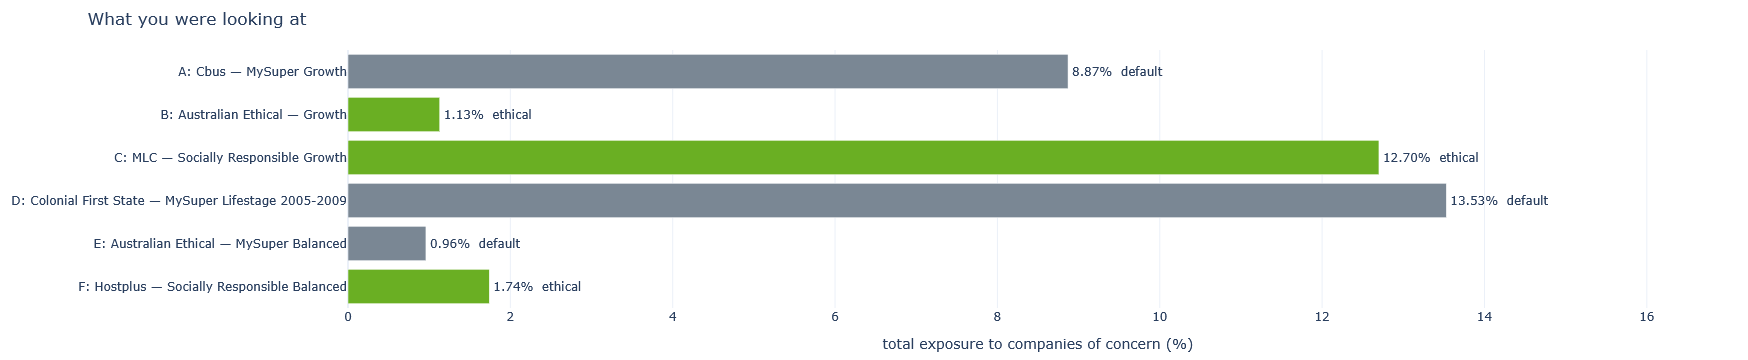

In [5]:
# --- reveal and score -----------------------------------------------------
truth = PANEL.set_index("name").loc[ROUND1, "fund_type"].map(
    {"Ethical": "ethical", "MySuper": "default"}).tolist()

if "?" in MY_LABELS:
    print("Go back and fill in MY_LABELS first.")
else:
    correct = 0
    print(f"    {'your answer':<12s}{'truth':<10s}{'total':>7s}   the option")
    print("-" * 78)
    for letter, guess, t, name in zip(LETTERS, MY_LABELS, truth, ROUND1):
        hit = guess == t
        correct += hit
        tot = PANEL.set_index("name").loc[name, "total"]
        print(f" {letter}  {guess:<12s}{t:<10s}{tot:7.2f}   {name}{'' if hit else '   <-- missed'}")
    SCORE["round1"] = correct
    print(f"\nRound 1 score: {correct} out of 6")

tot = PANEL.set_index("name").loc[ROUND1, "total"]
fig = go.Figure(go.Bar(
    x=tot.values, y=[f"{l}: {n}" for l, n in zip(LETTERS, ROUND1)], orientation="h",
    marker_color=["#6AAF23" if t == "ethical" else "#7A8794" for t in truth],
    text=[f"{v:.2f}%  {t}" for v, t in zip(tot.values, truth)], textposition="outside"))
fig.update_layout(template="plotly_white", height=360, title="What you were looking at",
                  xaxis_title="total exposure to companies of concern (%)",
                  xaxis_range=[0, 17], yaxis_autorange="reversed",
                  margin=dict(l=10, r=20, t=50, b=40))
fig.show()

### How to read that

The two traps pull in **opposite directions**.

**C is MLC's Socially Responsible Growth option.** It is sold as ethical, and
12.70% of its analysed portfolio sits in companies of concern — more than MLC's
own default, and more than most of the defaults in the whole panel. If you
called it a default, you read the numbers correctly and the label wrongly.

**E is Australian Ethical's MySuper Balanced option.** It is a default: it is
where a member lands without choosing. It is also the **cleanest option of all
thirty-one**, at 0.96%. Its provider only sells ethical products, so its default
is ethical too. The label here lives at the level of the *provider*, not the
option.

Now look at B and E together. Two portfolios, almost identical to the second
decimal place. One carries the ethical label and one does not.

So the total does not reveal the label. **But one of the six columns comes very
close to doing so.** Look back at the table before you start Round 2. Which one
is it?

---
# Round 2 — What gives it away?

### Why we are doing this

A label can be strong on some categories and silent on others. Before we can
audit a label, we need to know which parts of it are doing any work.

### What is about to happen

For each category, imagine every possible pairing of one ethical option with
one default — 16 × 15 = 240 pairs. In what share of those pairs is the ethical
option the *cleaner* of the two?

* **1.0** means every ethical option beats every default on that category. The
  label separates it perfectly.
* **0.5** means a coin flip. On that category, the label tells you nothing.

That share has a name, the **area under the ROC curve** or AUC, and you will
meet it properly in Lab 9a. For now it is just "how often the label wins a
head-to-head".

### Your guess

Which category do you think the label separates **best**, and which **worst**?
Choose from: Fossil fuels, Human rights, Environmental harm, Social harm,
Animal cruelty, Weapons.

In [6]:
# EDIT THIS. Exactly as spelled in the list above.
MY_BEST = "?"
MY_WORST = "?"

names = {v.lower(): k for k, v in CATEGORIES.items()}
if "?" in (MY_BEST, MY_WORST):
    print("Not finished yet.")
elif MY_BEST.lower() not in names or MY_WORST.lower() not in names:
    print("Check the spelling against:", ", ".join(CATEGORIES.values()))
else:
    print(f"Recorded: best = {MY_BEST}, worst = {MY_WORST}. Run the next cell.")

Not finished yet.


  Social harm          0.958   (sector)
  Fossil fuels         0.877   (sector)
  Environmental harm   0.854   (mixed)
  Weapons              0.846   (sector)
  Human rights         0.579   (conduct)
  Animal cruelty       0.542   (mixed)


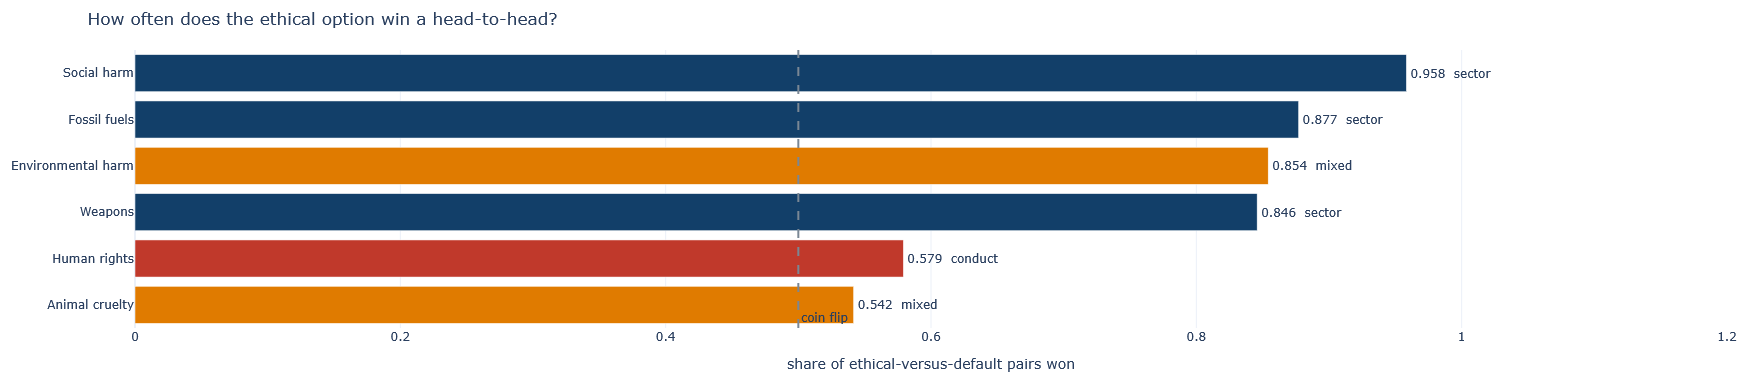

In [7]:
# --- reveal and score -----------------------------------------------------
def cleaner_share(x, is_ethical):
    """Share of (ethical, default) pairs in which the ethical option is cleaner.

    Ties count as half a win. This is exactly the AUC of the rule
    'lower exposure means ethical'.
    """
    e, d = x[is_ethical], x[~is_ethical]
    wins = (e[:, None] < d[None, :]).sum() + 0.5 * (e[:, None] == d[None, :]).sum()
    return wins / (len(e) * len(d))

KIND = {"fossil": "sector", "social_harm": "sector", "weapons": "sector",
        "human_rights": "conduct", "env_harm": "mixed", "animal": "mixed"}

auc = pd.Series({k: cleaner_share(PANEL[k].to_numpy(), IS_ETHICAL) for k in CATEGORIES})
ranked = auc.sort_values(ascending=False)
order = [CATEGORIES[k] for k in ranked.index]

if "?" not in (MY_BEST, MY_WORST):
    pts = 0
    pts += 2 if MY_BEST.lower() == order[0].lower() else (1 if MY_BEST.lower() == order[1].lower() else 0)
    pts += 2 if MY_WORST.lower() == order[-1].lower() else (1 if MY_WORST.lower() == order[-2].lower() else 0)
    SCORE["round2"] = pts
    print(f"Best is {order[0]}, worst is {order[-1]}.  Round 2 score: {pts} out of 4\n")

for k, v in ranked.items():
    print(f"  {CATEGORIES[k]:20s} {v:.3f}   ({KIND[k]})")

colour = {"sector": "#123F69", "mixed": "#E07B00", "conduct": "#C0392B"}
r = ranked.iloc[::-1]
fig = go.Figure(go.Bar(x=r.values, y=[CATEGORIES[k] for k in r.index], orientation="h",
                       marker_color=[colour[KIND[k]] for k in r.index],
                       text=[f"{v:.3f}  {KIND[k]}" for k, v in r.items()],
                       textposition="outside"))
fig.add_vline(x=0.5, line_dash="dash", line_color="#7A8794",
              annotation_text="coin flip", annotation_position="bottom right")
fig.update_layout(template="plotly_white", height=380, xaxis_range=[0, 1.2],
                  title="How often does the ethical option win a head-to-head?",
                  xaxis_title="share of ethical-versus-default pairs won",
                  margin=dict(l=10, r=20, t=50, b=40))
fig.show()

### How to read that

The colours are the source's own distinction between two kinds of concern.

**Sector** categories (navy) are binary: a company either earns revenue above a
threshold in a harmful industry or it does not. Tobacco is tobacco. These are
cheap to screen and easy to check.

**Conduct** categories (red) are judgements about how a company behaves, built
from controversy research. Human rights is the pure case. The two mixed
categories (orange) contain a bit of both.

The label separates the sector categories well and **barely separates human
rights at all** — and on animal cruelty the ethical options are, on average, no
cleaner than the defaults. Keep that in mind when you remember that, in the
survey accompanying this data, **87% of Australians** said they want their super
to avoid human rights violations.

---
# Round 3 — Write the industry's rule

### Why we are doing this

If the label really is mostly one screen, you should be able to write that
screen down in one line and reproduce the label from the holdings.

### The game

Pick **one category** and **one threshold**. Your rule is:

> an option is ethical if its exposure in that category is below the threshold.

Your rule is applied to all thirty-one options. Every option it gets wrong is
an error. You score **6 minus the number of errors**, with a floor of zero.
Try as many rules as you like; your best attempt counts.

Set `MY_THRESHOLD` in percentage points, for example `2.5` for 2.5%.

In [8]:
# EDIT THIS, then run. Re-run with different rules as often as you like.
MY_CATEGORY = "?"      # e.g. "Fossil fuels"
MY_THRESHOLD = None    # e.g. 2.5

key = {v.lower(): k for k, v in CATEGORIES.items()}.get(str(MY_CATEGORY).lower())
if key is None or MY_THRESHOLD is None:
    print("Set MY_CATEGORY to one of:", ", ".join(CATEGORIES.values()),
          "\nand MY_THRESHOLD to a number.")
else:
    predicted = PANEL[key].to_numpy() < MY_THRESHOLD
    wrong = predicted != IS_ETHICAL
    pts = max(0, 6 - int(wrong.sum()))
    SCORE["round3"] = max(SCORE["round3"], pts)
    print(f"Rule: ethical if {CATEGORIES[key]} < {MY_THRESHOLD}%")
    print(f"Errors: {wrong.sum()} of {len(PANEL)}   ->   {pts} points "
          f"(best so far: {SCORE['round3']})\n")
    for n, p, t in zip(PANEL.loc[wrong, "name"], predicted[wrong], IS_ETHICAL[wrong]):
        print(f"   called {'ethical' if p else 'default':8s} but is {'ethical' if t else 'default':8s}  {n}")

Set MY_CATEGORY to one of: Fossil fuels, Human rights, Environmental harm, Social harm, Animal cruelty, Weapons 
and MY_THRESHOLD to a number.


Knowing nothing and calling everything by the larger class makes 15 errors.

              category  best threshold (%)  errors
           Social harm                0.66       1
          Fossil fuels                3.32       3
    Environmental harm                1.01       4
Total (all categories)                6.50       4
               Weapons                0.53       5
          Human rights                1.78      11
        Animal cruelty                1.00      11


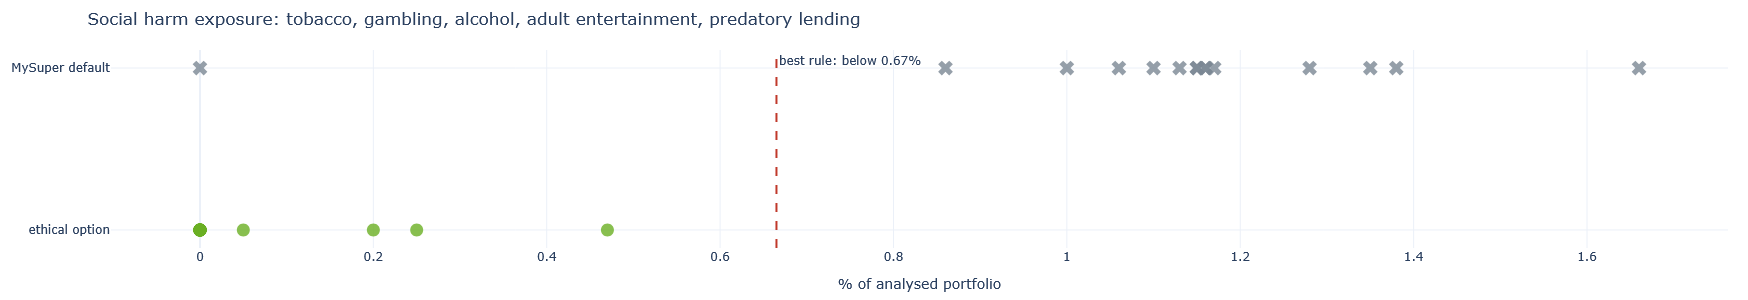

In [9]:
# --- reveal: the best one-line rule for every category ---------------------
def best_rule(x, y):
    v = np.unique(x)
    cands = np.r_[v[0] - 0.01, (v[:-1] + v[1:]) / 2, v[-1] + 0.01]
    errs = np.array([((x < t) != y).sum() for t in cands])
    return cands[errs.argmin()], int(errs.min())

rows = []
for k in list(CATEGORIES) + ["total"]:
    t, e = best_rule(PANEL[k].to_numpy(), IS_ETHICAL)
    rows.append((CATEGORIES.get(k, "Total (all categories)"), round(t, 2), e))
best = pd.DataFrame(rows, columns=["category", "best threshold (%)", "errors"]).sort_values("errors")
baseline = min(IS_ETHICAL.sum(), (~IS_ETHICAL).sum())
print(f"Knowing nothing and calling everything by the larger class makes {baseline} errors.\n")
print(best.to_string(index=False))

t_best, _ = best_rule(PANEL["social_harm"].to_numpy(), IS_ETHICAL)
fig = go.Figure()
for eth, col, sym, nm in [(True, "#6AAF23", "circle", "ethical option"),
                          (False, "#7A8794", "x", "MySuper default")]:
    m = IS_ETHICAL == eth
    fig.add_trace(go.Scatter(x=PANEL.loc[m, "social_harm"], y=[nm] * int(m.sum()),
                             mode="markers", name=nm, text=PANEL.loc[m, "name"],
                             marker=dict(color=col, size=13, symbol=sym, opacity=0.8),
                             hovertemplate="%{text}: %{x:.2f}%<extra></extra>"))
fig.add_vline(x=t_best, line_dash="dash", line_color="#C0392B",
              annotation_text=f"best rule: below {t_best:.2f}%")
fig.update_layout(template="plotly_white", height=300, showlegend=False,
                  title="Social harm exposure: tobacco, gambling, alcohol, adult entertainment, predatory lending",
                  xaxis_title="% of analysed portfolio", margin=dict(l=10, r=20, t=50, b=40))
fig.show()

### How to read that

**One line on social harm reproduces the label with a single error in
thirty-one.** Every ethical option in the panel — including the ones that hold
more than their own default overall — keeps tobacco, gambling and alcohol below
half a per cent. Every default but one holds more than that.

The one exception, and the rule's single error, is Australian Ethical's default:
the provider that sells nothing but ethical products.

Now compare the total. A threshold on *total* exposure, which is the closest
thing we have to "how clean is this portfolio overall", makes more errors than
the social-harm rule does. The label tracks one particular screen better than it
tracks overall cleanliness.

### The twist

Now try the rule that members say they want most. Set `MY_CATEGORY` to
`"Human rights"` and hunt for the best threshold you can find. Compare your
error count with the baseline printed above — the number of errors you would
make by knowing nothing at all.

In [10]:
# --- final score ----------------------------------------------------------
total = sum(SCORE.values())
print(f"Round 1: {SCORE['round1']} / 6")
print(f"Round 2: {SCORE['round2']} / 4")
print(f"Round 3: {SCORE['round3']} / 6")
print(f"\nTotal:   {total} / 16")

Round 1: 4 / 6
Round 2: 0 / 4
Round 3: 0 / 6

Total:   4 / 16


---
## What just happened

1. **The total does not reveal the label.** An ethical option can hold more
   companies of concern than most defaults, and a default can be the cleanest
   option in the market.
2. **The label separates *sector* categories and barely separates *conduct*.**
   Tobacco, gambling, alcohol, fossil fuels and weapons are revenue tests: cheap
   to apply, easy to check. Human rights is a judgement, and it is where the
   label is weakest — although it is the issue members name first.
3. **In practice, "ethical" in Australian super is very close to a single
   vice-sector screen.** One threshold reproduces the label almost perfectly,
   and its only miss is a default from a provider whose whole range is ethical.

Everything you just did used the label as the answer and asked whether you
could match it. The lecture turns that around.

### Where this goes next

In **Lab 9a** you will cluster these thirty-one options *without ever showing
the algorithm the label*, then score the clusters against it. The label becomes
the thing under test rather than the thing you are trying to hit. You will find
the same three kinds of product you met here — and one option that no
algorithm can find a peer for.